In [1]:
import scanpy as sc
import infercnvpy as cnv
import pandas as pd
from scipy import sparse as sp

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [ ]:
### read in raw data (before HVG selection)

adata_dir = large_data_dir + 'cr_decrosslink_BC002_sample_filtered_feature_bc_matrix.h5'

adata = sc.read_10x_h5(adata_dir)

sc.pp.calculate_qc_metrics(adata, inplace = True)

### normalize and log-transform the data

sc.pp.normalize_total(adata, inplace = True)
sc.pp.log1p(adata)

In [ ]:
processed_adata = sc.read_h5ad(large_data_dir + 'GBM_BC002_genotyped.h5ad')
### filter adata to match processed_adata
adata = adata[adata.obs_names.isin(processed_adata.obs_names)].copy()
adata.obs = adata.obs.loc[processed_adata.obs_names]
adata.obsm['X_umap'] = processed_adata.obsm['X_umap']
adata.obsm['genotypes'] = processed_adata.obsm['genotypes']
adata.obs['pheno_leiden'] = processed_adata.obs['pheno_leiden']
adata.uns = processed_adata.uns


In [4]:
chr_table = pd.read_csv('../data/hg38_gencode_v27.txt', sep='\t', header=None, on_bad_lines='skip', index_col=0)
chr_table.columns = ['chromosome', 'start','end']
adata.var = adata.var.merge(chr_table, left_index=True, right_index=True, how='left')

In [5]:
%%time
cnv.tl.infercnv(
    adata,
    reference_key="pheno_leiden",
    reference_cat=[11],
    window_size=100,
    step=1, calculate_gene_values = False
)

  0%|          | 0/3 [00:00<?, ?it/s]

CPU times: user 349 ms, sys: 707 ms, total: 1.06 s
Wall time: 7.87 s


Finding 200 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.48288893699645996 seconds
Jaccard graph constructed in 17.142014503479004 seconds
Running Leiden optimization
Leiden completed in 9.744571447372437 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 30.16602849960327 seconds


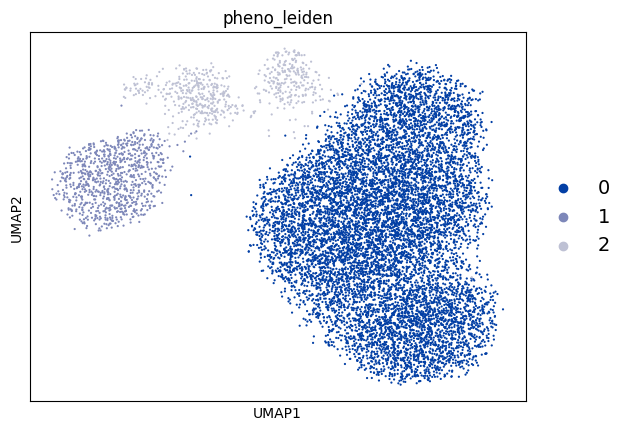

/tmp/ipykernel_3200449/2892017593.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_proportions = adata_infercnv.obs.groupby('pheno_leiden_expression')['pheno_leiden'].value_counts(normalize=True).unstack().fillna(0)


In [6]:
adata_infercnv = sc.AnnData(X=adata.obsm['X_cnv'].copy())
adata_infercnv.obs_names = adata.obs_names.copy()

sc.tl.pca(adata_infercnv, n_comps=100)

n_PCs = 20
adata_infercnv.obsm['X_pca'] = adata_infercnv.obsm['X_pca'][:, 0:n_PCs]
adata_infercnv.varm['PCs'] = adata_infercnv.varm['PCs'][:, 0:n_PCs]

sc.pp.neighbors(adata_infercnv, n_neighbors=30, use_rep='X_pca', metric='euclidean', key_added='neighbors_30')
sc.tl.umap(adata_infercnv, neighbors_key = 'neighbors_30', min_dist=1)

sc.external.tl.phenograph(adata_infercnv, clustering_algo='leiden', k=200, jaccard=True, primary_metric='euclidean', 
                          resolution_parameter=0.05)
sc.pl.umap(adata_infercnv, color = ['pheno_leiden'], s = 10, palette = sc.pl.palettes.zeileis_28, legend_fontsize = 14)

adata_infercnv.obs['pheno_leiden_expression'] = adata_infercnv.obs.index.map(adata.obs['pheno_leiden'].to_dict()).astype('category')
cluster_proportions = adata_infercnv.obs.groupby('pheno_leiden_expression')['pheno_leiden'].value_counts(normalize=True).unstack().fillna(0)

adata.obs['infercnv'] = adata.obs.index.map(adata_infercnv.obs['pheno_leiden'].to_dict()).astype('category').map({0:'tumor',1:'normal',2:'normal'})


In [ ]:
start = adata.uns['cnv']['chr_pos']['chr7']
end = adata.uns['cnv']['chr_pos']['chr8']
adata.obs['chr7_copy_number'] = adata.obsm['X_cnv'][:,start:end].mean(axis=1).A1

start = adata.uns['cnv']['chr_pos']['chr10']
end = adata.uns['cnv']['chr_pos']['chr11']
adata.obs['chr10_copy_number'] = adata.obsm['X_cnv'][:,start:end].mean(axis=1).A1

adata.obs[['chr7_copy_number','chr10_copy_number']].to_csv('../output/chr7_chr10_copy_number_infercnv.txt', sep='\t', header=True)

adata.write_h5ad('../output/GBM_BC002_infercnv.h5ad')

adata.obs['infercnv'].to_csv('../output/tumor_normal_labels_infercnv.txt', sep='\t', header=True)